In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import numpy as np

Retrieve reddit data

In [165]:
path = "data/data_reddit_query"
dfs = []
for filename in os.listdir(path):
    with open(os.path.join(path, filename), "r", encoding="utf-8") as file:
        data = json.load(file)
        try:
            data = data["data"]
            data = data["children"]
            df = pd.json_normalize(data)
            dfs.append(df)
        except:
            pass

df_reddit = pd.concat(dfs, ignore_index=True)

/tmp/ipykernel_58894/2679303168.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_reddit = pd.concat(dfs, ignore_index=True)


Method 1 for classify the data

In [167]:
in_favor_keywords = ["support", "agree", "yes", "pro"]
against_keywords = ["oppose", "no", "disagree", "against", "stopped", "ban", "block"]

def classify_text(text):
    if not isinstance(text, str):
        return np.nan  # Handle non-string values (e.g., NaN or missing data)
    text_lower = text.lower()
    in_favor_count = sum(keyword in text_lower for keyword in in_favor_keywords)
    against_count = sum(keyword in text_lower for keyword in against_keywords)
    if in_favor_count > against_count:
        return 1
    elif against_count > in_favor_count:
        return 0

In [168]:

df_reddit['text'] = df_reddit['data.title'] + ',' + df_reddit['data.selftext']
df_reddit["favor_classification"] = df_reddit["text"].apply(classify_text)

/tmp/ipykernel_58894/3286081664.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_reddit['text'] = df_reddit['data.title'] + ',' + df_reddit['data.selftext']
/tmp/ipykernel_58894/3286081664.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_reddit["favor_classification"] = df_reddit["text"].apply(classify_text)


In [169]:
df_reddit["data_name"] = "Reddit"

/tmp/ipykernel_58894/1115142437.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_reddit["data_name"] = "Reddit"


In [174]:
    
# The df's need to have atleast 3 columns. text (all the text we do the processing on) and data_name (name of the data source)
def classify_dfs(dfs):

    classified_df = pd.DataFrame(columns=["data_name", "favor_classification_score", "no_data_points"])

    for i in dfs:
        df_used = i.copy()
        df_used["favor_classification"] = df_used["text"].apply(classify_text)
        # Replace 'Unknown' with NaN (those that didnt get a score)
        df_used["favor_classification"] = df_used["favor_classification"].replace('Unknown', np.nan)

        # Convert the column to float
        df_used["favor_classification"] = pd.to_numeric(df_used["favor_classification"], errors='coerce')
        df_used = df_used.dropna(subset=['favor_classification'])
        df_used = df_used.astype({'favor_classification': float})

        df = pd.DataFrame({
            "data_name": [df_used['data_name'].iloc[0]],
            "favor_classification_score": [df_used["favor_classification"].mean()],
            "no_data_points": [len(i)]
        })

        classified_df = pd.concat([classified_df, df], ignore_index=True)

    return classified_df




In [175]:
classify_dfs([df_reddit])

/tmp/ipykernel_58894/1203442663.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  classified_df = pd.concat([classified_df, df], ignore_index=True)


,data_name,favor_classification_score,no_data_points
0,Reddit,0.3675,938


In [179]:
def favor_score(df):

    plt.axvline(x=0.5, linestyle='-', color='blue', label='Neutral Line (0.5)')

    for i in df.iterrows():
        x = i[1]['favor_classification_score']
        y = i[1]['no_data_points']
        label = i[1]['data_name']
        plt.plot(x, y, marker='o', markersize=8, color='red', label=label)
        plt.text(x, y+(y*0.005), ' ' + label, verticalalignment='center_baseline', fontsize=10)


    # Customize the plot
    plt.xlabel("Proportion in Favor")
    plt.ylabel("Number of datapoints")
    plt.xlim(0, 1)
    plt.title("Sentiment on Chat Control")
    plt.grid(True)
    #plt.legend()
    plt.show()

/tmp/ipykernel_58894/1203442663.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  classified_df = pd.concat([classified_df, df], ignore_index=True)


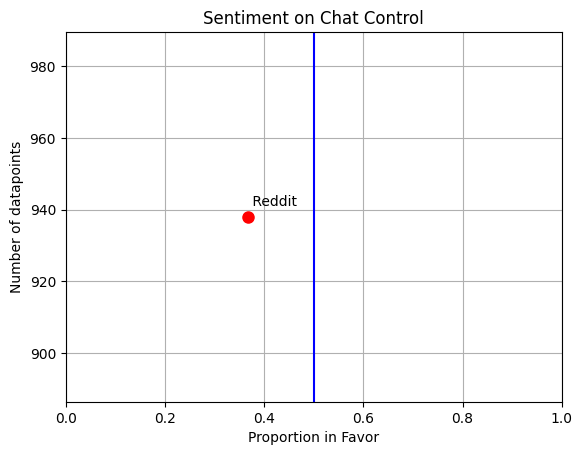

In [181]:
favor_score(classify_dfs([df_reddit]))